# Egypt Agriculture (FAOSTAT) — Linear Regression Model

**Final Project — GDG Al-Zaher | Data Science 2026**

Workflow: **Baseline → Preprocessing → Linear Regression → Evaluation → Interpretation → Error Analysis**

## 1. Load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

TARGET = "Yield"
FEATURES_NUM = [
    "Yield_Lag1", "Yield_Lag2", "Production_Lag1", "Area_Lag1",
    "Yield_RollingMean_3Y", "Area_Growth_Lag1", "Production_Growth_Lag1",
]

print("Train shape:", train.shape, "| Year range:", train["Year"].min(), "-", train["Year"].max())
print("Test shape :", test.shape, "| Year range:", test["Year"].min(), "-", test["Year"].max())
print("\nCrops (Item) in train:", train["Item"].nunique(), "| in test:", test["Item"].nunique())
unseen_items = set(test["Item"].unique()) - set(train["Item"].unique())
print("Crops present in test but not in train:", unseen_items)

train.head()

Train shape: (3502, 10) | Year range: 1964 - 2013
Test shape : (827, 10) | Year range: 2014 - 2024

Crops (Item) in train: 76 | in test: 77
Crops present in test but not in train: {'Avocados'}


,Item,Year,Yield_Lag1,Yield_Lag2,Production_Lag1,Area_Lag1,Yield_RollingMean_3Y,Area_Growth_Lag1,Production_Growth_Lag1,Yield
0,"Anise, badian, coriander, cumin, caraway, fenn...",1964,833.3,833.3,1000.0,1200.0,833.3,0.0,0.0,833.3
1,"Anise, badian, coriander, cumin, caraway, fenn...",1965,833.3,833.3,1000.0,1200.0,833.3,0.0,0.0,833.3
2,"Anise, badian, coriander, cumin, caraway, fenn...",1966,833.3,833.3,1000.0,1200.0,833.3,0.0,0.0,833.3
3,"Anise, badian, coriander, cumin, caraway, fenn...",1967,833.3,833.3,1000.0,1200.0,833.3,0.0,0.0,833.3
4,"Anise, badian, coriander, cumin, caraway, fenn...",1968,833.3,833.3,1000.0,1200.0,833.3,0.0,0.0,833.3


## 2. Baseline model

Before trying Linear Regression, we need a simple reference point. Since every row already carries **last year's yield** (`Yield_Lag1`), the most natural, honest baseline for a yield-prediction task is a **persistence baseline**: *"assume this year's yield equals last year's yield."* Any real model should beat this.

In [2]:
baseline_pred = test["Yield_Lag1"]

baseline_mae = mean_absolute_error(test[TARGET], baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(test[TARGET], baseline_pred))
baseline_r2 = r2_score(test[TARGET], baseline_pred)

print("Persistence baseline (predict Yield_Lag1):")
print(f"  MAE  = {baseline_mae:,.2f}")
print(f"  RMSE = {baseline_rmse:,.2f}")
print(f"  R2   = {baseline_r2:.4f}")

Persistence baseline (predict Yield_Lag1):
  MAE  = 929.06
  RMSE = 2,671.85
  R2   = 0.9733


## 3. Preprocessing

`Item` is categorical (76 crops) and the numeric lag features live on very different scales (Area in hectares vs. growth rates as small decimals), so Linear Regression needs both **encoding** and **scaling**. Both are **fit on train only** and then applied to test, to avoid data leakage.

In [3]:
# One-hot encode the crop name
train_oh = pd.get_dummies(train, columns=["Item"], prefix="Item")
test_oh = pd.get_dummies(test, columns=["Item"], prefix="Item")

test_oh = test_oh.reindex(columns=train_oh.columns, fill_value=0)

X_train, y_train = train_oh.drop(columns=[TARGET]), train_oh[TARGET]
X_test, y_test = test_oh.drop(columns=[TARGET]), test_oh[TARGET]

# Scale only the numeric lag features (fit on train, applied to test)
scaler = StandardScaler()
X_train[FEATURES_NUM] = scaler.fit_transform(X_train[FEATURES_NUM])
X_test[FEATURES_NUM] = scaler.transform(X_test[FEATURES_NUM])

print("Final feature matrix:", X_train.shape, "(train) /", X_test.shape, "(test)")

Final feature matrix: (3502, 84) (train) / (827, 84) (test)


## 4. Train the Linear Regression model

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print("Model trained on", X_train.shape[0], "rows and", X_train.shape[1], "features.")

Model trained on 3502 rows and 84 features.


## 5. Evaluation

We use **MAE** (average error in the same units as Yield, robust to outliers), **RMSE** (penalizes large errors more, same units), and **R²** (share of variance explained) — reporting all three rather than one, since each tells a different part of the story.

,Model,MAE,RMSE,R2
0,Baseline (persistence),929.056,2671.851,0.973
1,Linear Regression (train),1015.346,1952.686,0.982
2,Linear Regression (test),1094.608,2370.043,0.979


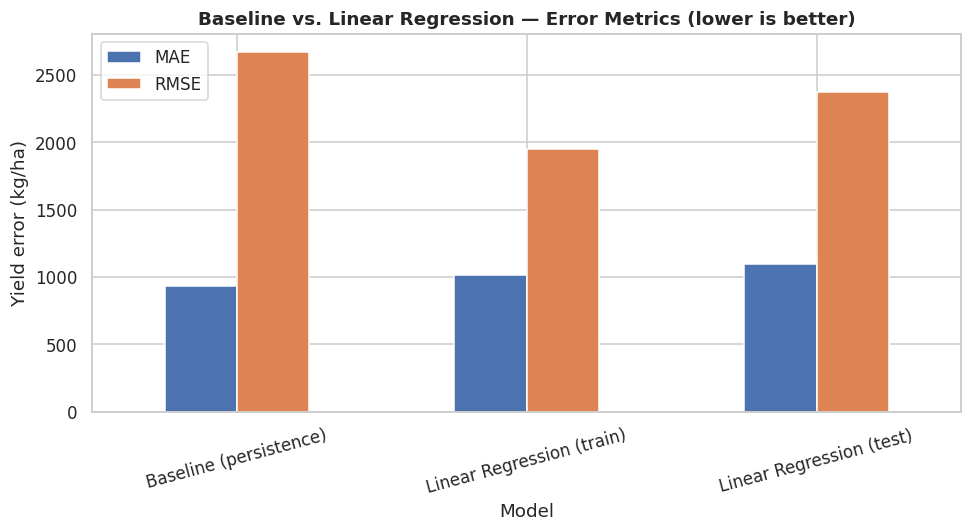

In [7]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = pd.DataFrame([
    evaluate(test[TARGET], baseline_pred, "Baseline (persistence)"),
    evaluate(y_train, pred_train, "Linear Regression (train)"),
    evaluate(y_test, pred_test, "Linear Regression (test)"),
])
display(results.round(3))

ax = results.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(9, 5), color=["#4C72B0", "#DD8452"])
plt.title("Baseline vs. Linear Regression — Error Metrics (lower is better)", weight="bold")
plt.ylabel("Yield error (kg/ha)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Insight:** Linear Regression **improves RMSE** over the naive persistence baseline (2,370 vs. 2,672 — about 11% lower) and edges out R² (0.979 vs. 0.973), meaning it does noticeably better on the years with the biggest jumps/drops. But it is **slightly worse on MAE** (1,095 vs. 929), meaning that for the *typical* crop-year, simply repeating last year's yield is already a very strong guess, and the linear model's improvements are concentrated in a minority of harder cases. Train vs. test performance (MAE 1,015 vs. 1,095; R² 0.982 vs. 0.979) is close, so the model is not meaningfully overfitting — it is a genuinely weak baseline that is hard to beat by a small margin, not a case of memorizing the training years.

## 6. Model interpretation

Which features and which crops does the model rely on most? Because the numeric features were standardized, their coefficients are directly comparable to each other.

--- Numeric feature coefficients (standardized) ---
Yield_Lag1                7309.2
Yield_RollingMean_3Y      5643.7
Production_Lag1            637.8
Yield_Lag2                -615.7
Area_Lag1                 -357.2
Area_Growth_Lag1           -80.4
Production_Growth_Lag1      51.1
dtype: float64


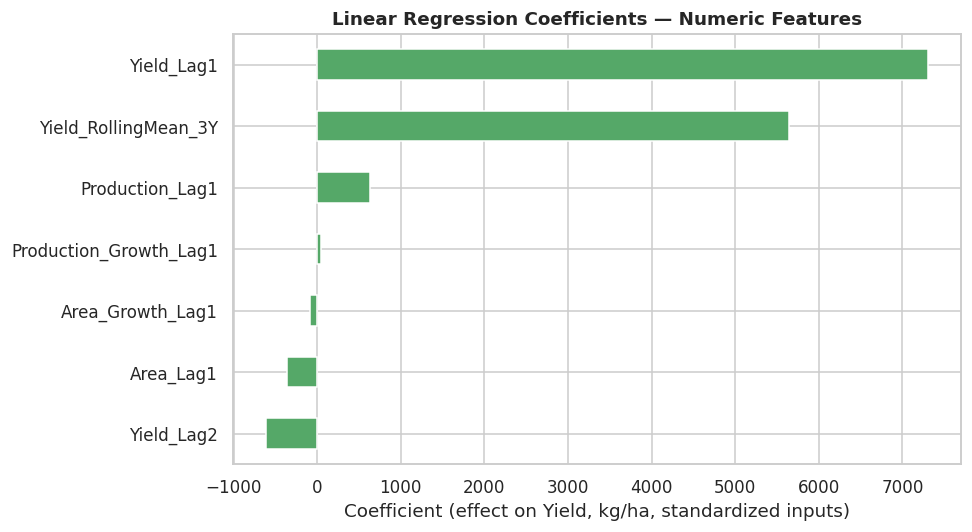

In [8]:
coefs = pd.Series(model.coef_, index=X_train.columns)

num_coefs = coefs[FEATURES_NUM].sort_values(key=abs, ascending=False)
print("--- Numeric feature coefficients (standardized) ---")
print(num_coefs.round(1))

plt.figure(figsize=(9, 5))
num_coefs.sort_values().plot(kind="barh", color="#55A868")
plt.title("Linear Regression Coefficients — Numeric Features", weight="bold")
plt.xlabel("Coefficient (effect on Yield, kg/ha, standardized inputs)")
plt.tight_layout()
plt.show()

**Insight:** `Yield_Lag1` (last year's yield) and `Yield_RollingMean_3Y` (3-year average) dominate the model by far, which matches the persistence baseline's strong performance — yield this year is mostly *"yield last year, plus a small correction."* `Yield_Lag2` gets a **negative** coefficient once the other two are in the model; this is a multicollinearity artifact (Lag1, Lag2 and the rolling mean are all highly correlated with each other), not evidence that two-year-old yield actively hurts predictions — a limitation worth stating plainly rather than over-interpreting.

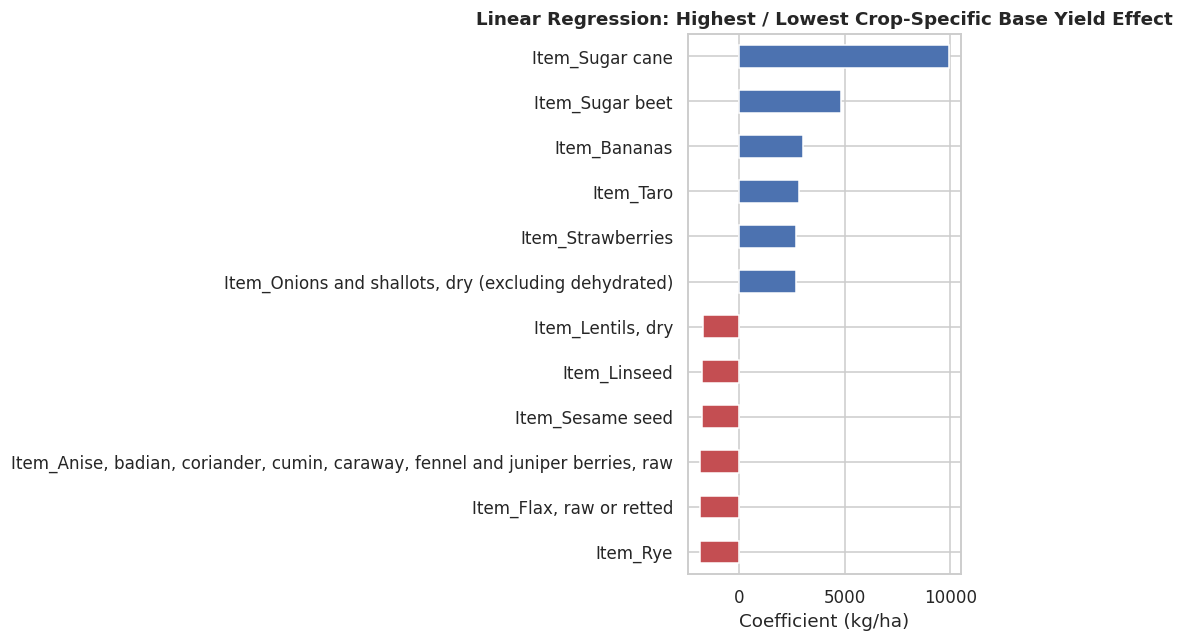

In [9]:
item_coefs = coefs[[c for c in coefs.index if c.startswith("Item_")]]

top_pos = item_coefs.sort_values(ascending=False).head(6)
top_neg = item_coefs.sort_values().head(6)
item_extremes = pd.concat([top_pos, top_neg]).sort_values()

plt.figure(figsize=(9, 6))
item_extremes.plot(kind="barh", color=["#C44E52" if v < 0 else "#4C72B0" for v in item_extremes.values])
plt.title("Linear Regression: Highest / Lowest Crop-Specific Base Yield Effect", weight="bold")
plt.xlabel("Coefficient (kg/ha)")
plt.tight_layout()
plt.show()

**Insight:** The crop dummies mainly capture each crop's **typical yield scale**, not a modeling insight by themselves. `Sugar cane` and `Sugar beet` get the largest positive offsets (real-world yields are routinely 80,000-120,000 kg/ha, far above other crops), while low-yield field crops like `Lentils`, `Chickpeas`, `Sesame seed` and `Rye` get negative offsets. This confirms the crop identity is doing real work in the model — without it, a single global intercept would badly under- or over-predict for crops at either extreme.

## 7. Error analysis

Where does the model go wrong?

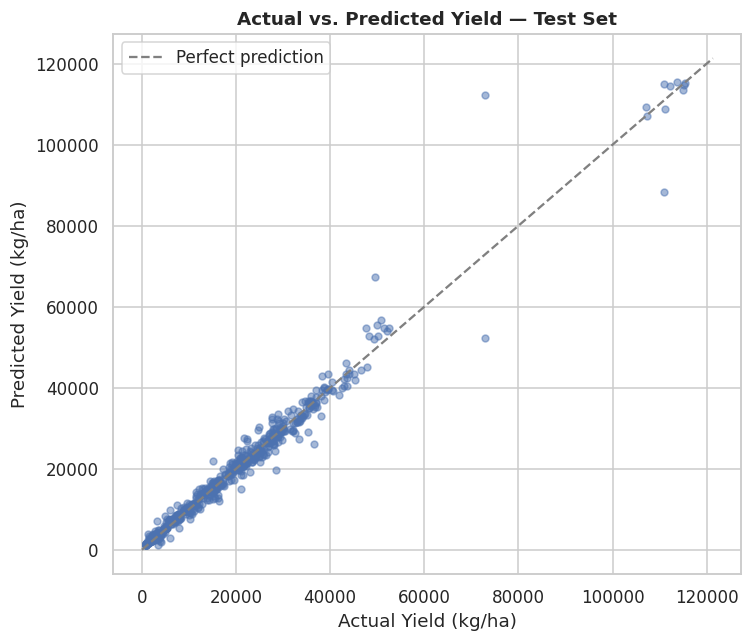

In [10]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred_test, alpha=0.5, s=20, color="#4C72B0")
lims = [0, max(y_test.max(), pred_test.max()) * 1.05]
plt.plot(lims, lims, "--", color="gray", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")
plt.title("Actual vs. Predicted Yield — Test Set", weight="bold")
plt.legend()
plt.tight_layout()
plt.show()

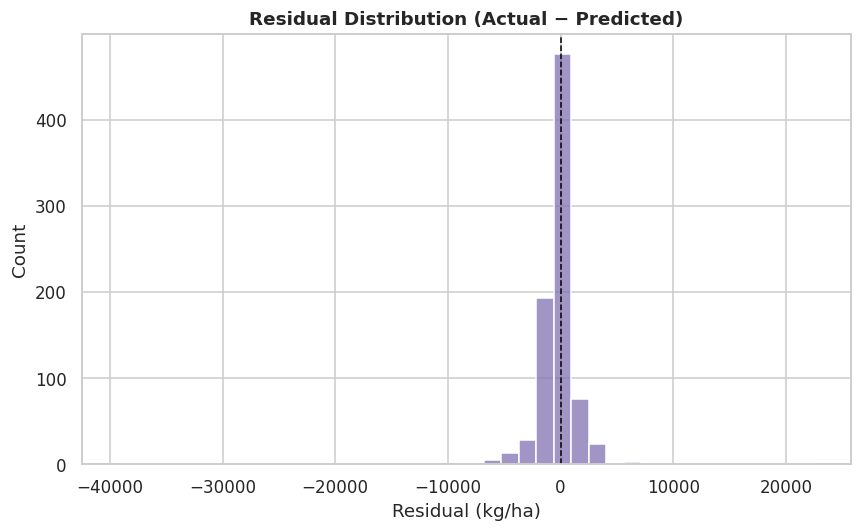

--- 10 largest absolute errors ---


,Item,Year,Yield,Predicted,Residual,AbsResidual
723,Sugar cane,2020,72879.7,112291.3,-39411.6,39411.6
724,Sugar cane,2021,110938.6,88247.5,22691.1,22691.1
712,Sugar beet,2020,72814.8,52320.6,20494.2,20494.2
713,Sugar beet,2021,49482.6,67458.6,-17976.0,17976.0
397,"Onions and shallots, dry (excluding dehydrated)",2014,36579.0,26160.1,10418.9,10418.9
40,Artichokes,2021,28523.9,19761.0,8762.9,8762.9
708,Sugar beet,2016,47660.7,54781.3,-7120.6,7120.6
260,Grapes,2020,15040.3,21845.2,-6804.9,6804.9
746,Sweet potatoes,2021,35227.2,29023.9,6203.3,6203.3
228,Eggplants (aubergines),2021,33457.9,27303.2,6154.7,6154.7



--- Mean absolute error by crop (worst 8) ---


,AbsResidual
Item,
Sugar cane,7021.1
Sugar beet,6777.8
Dates,2719.5
Watermelons,2370.5
Sweet potatoes,2241.3
Bananas,2181.2
Peaches and nectarines,2051.2
Artichokes,1813.7


In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(error_df["Residual"], bins=40, color="#8172B2")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Distribution (Actual − Predicted)", weight="bold")
plt.xlabel("Residual (kg/ha)")
plt.tight_layout()
plt.show()

print("--- 10 largest absolute errors ---")
display(error_df.sort_values("AbsResidual", ascending=False).head(10).round(1))

print("\n--- Mean absolute error by crop (worst 8) ---")
display(error_df.groupby("Item")["AbsResidual"].mean().sort_values(ascending=False).head(8).round(1))

In [18]:
residuals = y_test - pred_test

error_df = test[["Item", "Year", TARGET]].copy()
error_df["Predicted"] = pred_test
error_df["Residual"] = residuals.values
error_df["AbsResidual"] = error_df["Residual"].abs()

**Insight:** Errors are not evenly spread across crops — they are concentrated almost entirely in **Sugar cane and Sugar beet**, which dominate the 10 largest absolute errors and the worst mean-error crops. This is a direct consequence of their yield being 5-10x larger in scale than most other crops: the same *percentage* error translates into a much larger *absolute* error in kg/ha. Practically, this means the model's headline MAE/RMSE are pulled up by two crops, and a per-crop or log-scaled target could give a fairer picture — a good next step for the second model / model comparison stage.

## 8. Summary

- The **persistence baseline** (last year's yield) is already strong for this dataset — a sign that yield changes slowly and gradually for most crops, year to year.
- The **Linear Regression model beats the baseline on RMSE and R²** but not on MAE, meaning it helps most on the harder, larger swings rather than the typical case.
- The model is **not overfitting** (train and test metrics are close).
- **`Yield_Lag1` and the 3-year rolling mean are by far the strongest predictors**, confirming that recent history — not the crop's identity alone — drives most of the prediction.
- **Errors concentrate in Sugar cane and Sugar beet**, Egypt's highest-yield-scale crops, which is worth flagging as a limitation and a lead for the next modeling iteration (e.g. per-crop normalization, or a log-transformed target).

This sets up a clear reference point for the second model (e.g. Random Forest / Decision Tree Regressor) required by the project: it needs to beat an RMSE of ~2,370 and R² of ~0.979 to be considered an improvement over Linear Regression, and ideally also close the MAE gap with the persistence baseline.